<a href="https://colab.research.google.com/github/Skotchbizzy/Bloomview-Consult/blob/main/Final_Session_1_2_EMG%26EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1 style="color:maroon;">Robustness of Learned Feature Representations: A Comparative Analysis of Deep Learning Architectures for EMG Motor Task Recognition under Noisy Conditions</h1>

<h2 style="color:lightblue;">Research Objective</h2>
<p>The primary objective is to compare CNN, CNN-LSTM, and Attention CNN-LSTM feature representations extracted from electromyography (EMG) signals to determine which architecture remains most robust under noisy conditions</p>

<h2 style="color:lightblue;">Data Extraction</h1>
<p>Here to improve on efficiency will the systems was developed under subject 01 & 02 which both had session 1 & 2 data. Only we only require raw files as will perform our own pre-processing hence no need of loading the pre-processed data. </p>


<h3 style="color:lightblue;">Phase 1: Dataset Selection</h3>
The **Hyser dataset** was selected over CapgMyo and Ninapro due to its high spatial density (256 HD-sEMG channels), comprehensive participant pool (20 subjects), extensive gesture classes (34 gestures), and benchmark quality.

<h3 style="color:lightblue;">Data Description </h3>

1. File Pairs (.dat and .hea)
Every signal recording is split into two files:<br>
> .dat file: Stores the raw 16-bit binary signal values for all 256 HD-sEMG channels.<br>
> .hea file: The WFDB header file containing metadata (sampling rate of 2048 Hz, scaling factors, unit definitions, and channel count).

2. Task Types: dynamic vs. maintenance
> dynamic_* (1-second duration): Records the transition state from rest to performing a specific hand gesture.<br>
> maintenance_* (4-second duration): Records the sustained contraction holding a given gesture.

3. Label Files
> label_dynamic.txt & label_maintenance.txt: Plain text files containing comma-separated integers. Each integer corresponds to the ground-truth gesture ID (out of 34 gestures) for sample $k$ (e.g., sample1, sample2, ..., sampleN).


<h2 style="color:lightblue;">REFERENCE</h2>

1. Jiang, X., Dai, C., Liu, X., and Fan, J. (2023) 'Open Access Dataset and Toolbox of High-Density Surface Electromyogram Recordings' (version 2.0.0), PhysioNet. RRID:SCR_007345. Available at: https://doi.org/10.13026/hxan-pe94


<h2 style="color:lightblue;"> Data Mining and Extraction </h2>

In [ ]:
# To access the already downloaded High-Density Surface Electromyogram dataset,
# we will mount Google Drive to access it directly from cloud storage

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


<h2 style="color:lightblue;">Loading all the Dependencies </h2>

In [ ]:
!pip install -q wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 146.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [ ]:
%reset -f

In [ ]:
# Clearing all variables from the workspace to avoid any conflicts with previous runs
# also helps to free up memory and ensure that the notebook starts with a clean slate

In [ ]:
# Loading all modules
import numpy as np
import pandas as pd;pd.set_option("display.max_rows",None);pd.set_option("display.max_columns",None)
import wfdb;import gc;from tensorflow.keras import mixed_precision
import os;import glob;import math;import time;import re
import scipy.signal as signal
import matplotlib.pyplot as plt;import seaborn as sns
import matplotlib.ticker as ticker
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import friedmanchisquare


import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Dissertation Visualisation Export Setup

The cells below export dissertation-ready figures directly from Google Colab at 300 dpi.
Chapter 3 figures explain the experimental process; Chapter 4 figures present the experimental evidence.


In [ ]:
# Dissertation-quality figure export directory
FIG_DIR = "/content/drive/MyDrive/Dissertation_Figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_figure(filename):
    """Save the current Matplotlib figure at dissertation quality."""
    path = os.path.join(FIG_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")
    return path

print(f"Dissertation figures will be saved to: {FIG_DIR}")


Dissertation figures will be saved to: /content/drive/MyDrive/Dissertation_Figures


<h1 style="color:maroon;">Analysis Pipeline</h1>


Phase 1: Dataset Selection & Justification
> Evaluate CapgMyo, NinaPro, and Hyser datasets.

> Select Hyser: 256 HD-sEMG channels, 20 participants, 34 gestures, high spatial density.

Phase 2: Acquisition & Metadata Mining
> Download raw Hyser files from PhysioNet via WFDB / direct script.

> Extract metadata: sampling frequency (2048 Hz), electrode grid layout, session logs.

Phase 3: Data Ingestion & Structuring
> Parse .dat signal matrices and .hea headers.

> Map array shapes: (Time_Steps, 256 Channels) correlated to Subject ID, Session, & Gesture.

Phase 4: Exploratory Data Analysis (EDA)
> Inspect signal-to-noise baseline, missing/corrupted channels, and class distribution.

> Plot representative 256-channel array heatmaps and single-channel time-series waveforms.

Phase 5: Preprocessing & Grid Formulation
> Digital Filtering: 50 Hz Notch filter (Q=30) + 10-500 Hz 4th-order Bandpass filter.

> Spatial Formatting: Organize channels as 1D vectors or 2D grid topological matrices.

> Windowing: 300 ms sliding window with 50% overlap (150 ms stride).

> Normalization: Calculate Z-score parameters per-subject strictly within training sets.

Phase 6: Leakage-Free Dataset Partitioning
> Partition Split: Inter-subject split (e.g., 14 Train / 3 Val / 3 Test) for generalizability.

> Ensure zero overlap across window boundaries or subject identities across splits.

Phase 7: Network Architecture & Baseline Benchmarks
> Classical Baseline: Handcrafted TD/FD Features (RMS, MAV, WL, ZC) + LDA / SVM.
> Deep Models Implementation:
- Baseline 1D/2D CNN
- Hybrid CNN-LSTM
- Attention CNN-LSTM (Self-Attention / Temporal Attention)
- Training Protocol: Cross-Entropy loss, AdamW optimizer, Early Stopping on Val Loss.

Phase 8: Representation & Feature Extraction
> Extract penultimate bottleneck feature vectors (e.g., 128-dim dense outputs).

> Obtain direct Softmax gesture probabilities alongside bottleneck representations.

Phase 9: Clean Baseline Performance Benchmark
> Evaluate direct network outputs vs. offline LDA fitted on bottleneck embeddings.

> Record Metrics: Accuracy, Precision, Recall, Macro F1-Score, Confusion Matrices.

Phase 10: Multi-Modal Noise Injection Protocol
> Additive White Gaussian Noise (AWGN): Inject at 20 dB, 10 dB, 5 dB, 0 dB SNR.

> Motion & Drift Artifacts: Simulate low-frequency movement noise.

> Channel Dropouts: Randomly zero out 10%, 20%, and 30% of active electrode channels.

Phase 11: Robustness Evaluation Under Noise
> Pass noisy test sets through frozen model pipelines.

> Re-extract features, re-evaluate classifications, and measure performance degradation curves.

Phase 12: High-Dimensional Representation Visualisation
> Apply PCA to inspect primary linear variance components of penultimate features.

> Apply t-SNE / UMAP clustering to visualize gesture separation quality across noise levels.

Phase 13: Rigorous Statistical Significance Testing
> Normality Verification: Shapiro-Wilk test on classification metrics.

> Non-Parametric Hypothesis Testing: Friedman Test across models & noise levels.

> Post-hoc Analysis: Nemenyi or Wilcoxon signed-rank test with Bonferroni correction.

Phase 14: Trade-off & Efficiency Analysis
> Performance Degradation Rate: Measure % drop in F1-score per dB decrease in SNR.

> Computational Profile: Measure Inference Latency (ms), Memory Footprint (MB), Parameter Count, & FLOPs.

Phase 15: Decision Matrix & Research Synthesis
> Synthesize Accuracy vs. Robustness vs. Computational Latency trade-offs.

> Identify the optimal deep learning architecture for practical, noise-resilient HD-sEMG control.

<h2 style="color:lightblue">Defining Utility Functions</h2>

<h3 style="color:lightblue">Phase 2 & 3: Metadata Mining, Data Ingestion & Structuring</h3>
To efficiently process the 37.1GB PR dataset, we build a metadata index that associates every raw `.dat` file with its corresponding participant, session, and ground-truth gesture label. This prevents loading the entire dataset into memory simultaneously.

In [ ]:
def build_hyser_metadata_index(data_dir):
    """
    Parses directory structures and label files to create a structured mapping.
    This correlates recordings with participant IDs, sessions, and gesture labels[cite: 1].
    """
    records_meta = []

    # Define paths to label files
    dyn_label_file = os.path.join(data_dir, "label_dynamic.txt")
    maint_label_file = os.path.join(data_dir, "label_maintenance.txt")

    # Load raw labels into arrays if the files exist, otherwise set to None
    dyn_labels = (
        np.loadtxt(dyn_label_file, delimiter=",", dtype=int)
        if os.path.exists(dyn_label_file)
        else None
    )
    maint_labels = (
        np.loadtxt(maint_label_file, delimiter=",", dtype=int)
        if os.path.exists(maint_label_file)
        else None
    )

    # Extract subject and session identifiers from the folder name
    folder_name = os.path.basename(os.path.normpath(data_dir))
    parts = folder_name.split("_")
    subject_id = parts[0] if len(parts) > 0 else "subject01"
    session_id = parts[1] if len(parts) > 1 else "session1"

    # Identify all .hea files in the directory
    hea_files = glob.glob(os.path.join(data_dir, "*.hea"))

    for hea_path in hea_files:
        filename = os.path.basename(hea_path).replace(".hea", "")

        # Strict regex matching to avoid extracting subject/session numbers
        match = re.search(r"sample(\d+)", filename)
        if not match:
            continue
        sample_num = int(match.group(1))

        # Determine task type and corresponding gesture label based on filename
        if "dynamic" in filename:
            task_type = "dynamic"
            # Map 1-based gesture labels (1..34) to 0-based PyTorch targets (0..33)
            raw_label = (
                dyn_labels[sample_num - 1]
                if (dyn_labels is not None and sample_num <= len(dyn_labels))
                else -1
            )
            gesture_label = (
                int(raw_label) - 1 if raw_label > 0 else int(raw_label)
            )

        elif "maintenance" in filename:
            task_type = "maintenance"
            raw_label = (
                maint_labels[sample_num - 1]
                if (maint_labels is not None and sample_num <= len(maint_labels))
                else -1
            )
            gesture_label = (
                int(raw_label) - 1 if raw_label > 0 else int(raw_label)
            )
        else:
            continue

        # Append the structured metadata for the current recording to the list
        records_meta.append({
            "subject": subject_id,
            "session": session_id,
            "task_type": task_type,
            "sample_id": sample_num,
            "file_prefix": os.path.join(data_dir, filename),
            "gesture_label": gesture_label,
        })

    df_meta = pd.DataFrame(records_meta)
    if not df_meta.empty:
        df_meta = df_meta.sort_values(
            by=["task_type", "sample_id"]
        ).reset_index(drop=True)

    return df_meta

<h3 style="color:lightblue">Phase 4: Exploratory Data Analysis (EDA)</h3>
We inspect signal-to-noise baselines, waveform quality, and plot representative 256-channel array heatmaps alongside single-channel time-series waveforms.

<h3 style="color:lightblue">Phase 5: Preprocessing</h3>
The preprocessing pipeline applies:
1.  **Digital Filtering:** A 50 Hz Notch filter (Q=30) and a 10–500 Hz 4th-order Bandpass filter.
2.  **Windowing:** A 300 ms sliding window approach with a 50% overlap.
3.  **Normalization:** Z-score normalization strictly within local windows to ensure uniform input scaling without data leakage.

In [ ]:
def visualize_raw_emg_sample(df_meta, row_index=0, fs=2048):
    """
    Phase 4: Publication-Quality HD-sEMG Visualization
    - Applies Bandpass (10-500 Hz) & Notch (50 Hz) filtering first.
    - Uses Robust Scaling (99th Percentile) for 16x16 Heatmaps to prevent outliers from distorting contrast.
    - Plots Waveforms and Spatial Maps side-by-side for sleek presentation.
    """
    row = df_meta.iloc[row_index]
    rec = wfdb.rdrecord(row["file_prefix"])
    raw_sig = rec.p_signal  # (Samples, 256)

    # Apply Notch and Bandpass Filtering
    b_notch, a_notch = signal.iirnotch(50.0 / (0.5 * fs), Q=30.0)
    b_band, a_band = signal.butter(4, [10.0 / (0.5 * fs), 500.0 / (0.5 * fs)], btype='bandpass')

    filtered_sig = signal.filtfilt(b_notch, a_notch, raw_sig, axis=0)
    filtered_sig = signal.filtfilt(b_band, a_band, filtered_sig, axis=0)

    # Compute RMS values for each channel and reshape to 16x16 grid
    time_axis = np.arange(filtered_sig.shape[0]) / fs
    rms_values = np.sqrt(np.mean(filtered_sig ** 2, axis=0))
    rms_map = rms_values.reshape(16, 16)
    vmax_cap = np.percentile(rms_values, 98)

    # Plotting the filtered EMG signals and the corresponding spatial topography
    fig = plt.figure(figsize=(16, 6), dpi=120)
    gs = fig.add_gridspec(4, 2, width_ratios=[2, 1], wspace=0.3, hspace=0.15)

    selected_channels = [0, 64, 128, 192]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i, (ch, col) in enumerate(zip(selected_channels, colors)):
        ax = fig.add_subplot(gs[i, 0])
        ax.plot(time_axis, filtered_sig[:, ch], color=col, lw=0.9, label=f'Ch {ch}')
        ax.set_ylabel(f"Ch {ch}\n(mV)", fontsize=9, rotation=0, labelpad=25, va='center')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.tick_params(labelsize=8)
        if i < 3:
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Time (seconds)", fontsize=10, fontweight='bold')

    fig.suptitle(
        f"Phase 4 EDA: Filtered HD-sEMG Signal Quality & Spatial Topography\n"
        f"Subject: {row['subject'].upper()} | Gesture: {row['gesture_label']} | Task: {row['task_type'].capitalize()}",
        fontsize=13, fontweight='bold', y=0.98
    )

    ax_map = fig.add_subplot(gs[:, 1])
    sns.heatmap(
        rms_map,
        cmap="viridis",
        vmax=vmax_cap,
        annot=False,
        square=True,
        cbar_kws={'label': 'RMS Energy (mV) [Capped at 98th Pctl]', 'shrink': 0.8},
        ax=ax_map
    )
    ax_map.set_title("16x16 Electrode Activation Topography", fontsize=11, fontweight='bold', pad=12)
    ax_map.set_xlabel("Grid Column", fontsize=9)
    ax_map.set_ylabel("Grid Row", fontsize=9)
    ax_map.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()


In [ ]:
class HDsEMGDataset(Dataset):
    '''
    Created a PyTorch Dataset class to handle HD-sEMG data.
    It processes the metadata, applies digital filters,
    performs sliding window segmentation, normalizes the data,
    and applies dynamic augmentations like Additive White Gaussian Noise (AWGN) and channel dropout
    during data retrieval.
    '''

    def __init__(self, metadata_df, window_size=400, step_size=100, fs=2048, snr_db=None, channel_dropout=0.0):
        self.window_size = window_size
        self.step_size = step_size
        self.snr_db = snr_db
        self.channel_dropout = channel_dropout

        self.samples = []
        self.labels = []

        # Phase 5: Digital Filter Design (50Hz Notch & 10-500Hz Bandpass Filter)
        nyq = 0.5 * fs
        self.b_notch, self.a_notch = signal.iirnotch(50.0 / nyq, Q=30.0)
        self.b_band, self.a_band = signal.butter(4, [10.0 / nyq, 500.0 / nyq], btype='bandpass')

        # Process metadata rows
        self._process_metadata(metadata_df)

    def _apply_filters(self, data):
        # Data shape: (Time_Steps, Channels)
        filtered = signal.filtfilt(self.b_notch, self.a_notch, data, axis=0)
        filtered = signal.filtfilt(self.b_band, self.a_band, filtered, axis=0)
        return filtered

    def _inject_awgn(self, x_tensor):
        # phase 10: Inject Additive White Gaussian Noise (AWGN) based on the specified SNR in dB
        if self.snr_db is None:
            return x_tensor
        # x_tensor shape: (Channels, Time_Steps)
        sig_power = torch.mean(x_tensor ** 2, dim=-1, keepdim=True)
        snr_linear = 10 ** (self.snr_db / 10.0)
        noise_power = sig_power / (snr_linear + 1e-8)
        noise = torch.randn_like(x_tensor) * torch.sqrt(noise_power + 1e-8)
        return x_tensor + noise

    def _apply_channel_dropout(self, x_tensor):
        # simulate active electrode corruption by zeroing out channels
        if self.channel_dropout <= 0.0:
            return x_tensor
        # Shape: (Channels, 1) to mask out entire channels across time
        mask = (torch.rand(x_tensor.shape[0], 1) > self.channel_dropout).float()
        return x_tensor * mask

    def _process_metadata(self, metadata_df):
        for _, row in metadata_df.iterrows():
            file_prefix = row['file_prefix']
            gesture_label = row['gesture_label']

            # Skip invalid labels or missing ground truths
            if gesture_label == -1:
                continue

            try:
                rec = wfdb.rdrecord(file_prefix)
            except Exception as e:
                print(f"Skipping corrupt or missing file: {file_prefix} ({e})")
                continue

            raw_sig = rec.p_signal  # Shape: (Time_Steps, Channels)
            filtered_sig = self._apply_filters(raw_sig)

            # Phase 5: Sliding Windowing
            num_samples = filtered_sig.shape[0]
            for start in range(0, num_samples - self.window_size + 1, self.step_size):
                window = filtered_sig[start : start + self.window_size, :]

                # Z-Score Normalization strictly within the local sliding window
                mean = np.mean(window, axis=0, keepdims=True)
                std = np.std(window, axis=0, keepdims=True) + 1e-8
                norm_window = (window - mean) / std

                # Transpose to Channels-First shape: (Channels, Window_Size) -> (256, 400)
                tensor_win = torch.tensor(norm_window.T, dtype=torch.float32)

                self.samples.append(tensor_win)
                self.labels.append(gesture_label)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x = self.samples[idx]

        # Dynamic augmentations applied during on-the-fly fetch
        x = self._inject_awgn(x)
        x = self._apply_channel_dropout(x)

        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

<h3 style="color:lightblue">Phase 7: Baseline Training Architectures</h3>
We benchmark multiple models trained on clean EMG using subject-wise splits to test generalization.

* **BaselineCNN:** A standard 1D CNN serving as the baseline.
* **CNN-LSTM:** A hybrid model replacing adaptive pooling with an LSTM to capture temporal transitions in gestures.
* **Attention CNN-LSTM (HighPerfHDsEMGNet):** Advanced architecture taking 2D reshaped inputs (treating electrode grids as images) and applying self-attention over the sequence.

In [ ]:
class BaselineCNN(nn.Module):
    '''
    Standard 1D Convolutional Neural Network architecture for HD-sEMG classification.
    It consists of two convolutional layers followed by batch normalization, ReLU activations,
    and pooling layers. The extracted features are then passed through a fully connected layer
    to produce the final class logits. The model can also return the penultimate feature embeddings
    '''

    def __init__(self, in_channels=256, num_classes=34):
        super(BaselineCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.penultimate = nn.Linear(64, 128)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x, return_features=False):
        feat = torch.flatten(self.features(x), 1)
        emb = F.relu(self.penultimate(feat))
        if return_features:
            return emb
        return self.classifier(emb)

In [ ]:
class CNN_LSTM(nn.Module):
    '''
    Hybrid CNN-LSTM architecture for HD-sEMG classification.
    The model first extracts spatial features using 1D convolutional layers,
    then captures temporal dependencies with an LSTM layer. The final embeddings are passed
    through a fully connected layer to produce class logits.
    The model can also return the penultimate feature embeddings for downstream tasks or analysis.
    '''
    def __init__(self, in_channels=256, num_classes=34, hidden_dim=128):
        super(CNN_LSTM, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.lstm = nn.LSTM(input_size=64, hidden_size=hidden_dim, batch_first=True)
        self.penultimate = nn.Linear(hidden_dim, 128)
        self.classifier = nn.Linear(128, num_classes)

    def forward(self, x, return_features=False):
        c_out = self.conv(x).permute(0, 2, 1)  # (Batch, Seq, Feature)
        r_out, (h_n, _) = self.lstm(c_out)
        emb = F.relu(self.penultimate(h_n[-1]))
        if return_features:
            return emb
        return self.classifier(emb)

In [ ]:
class SpatialReshape(nn.Module):
    '''
    Restructures the 256-channel 1D HD-sEMG input into a 16x16 2D spatial grid format.
    This transformation allows the model to leverage spatial relationships between electrodes.
    The module takes the input tensor of shape (Batch, Channels=256, Time_Steps) and reshapes
    it to (Batch * Time_Steps, 1, 16, 16), treating each time step as a separate 2D image for
    subsequent processing in CNN layers. This is particularly useful for architectures that can
    exploit spatial correlations, such as CNNs, while still preserving the temporal dimension
    for sequence modeling.
    '''
    def __init__(self, grid_h=16, grid_w=16):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w

    def forward(self, x):
        # x shape: (batch_size, channels=256, time_steps)
        B, C, T = x.shape
        # Permute to sequence first, then reshape channel dimensions to 2D spatial grid
        x = x.permute(0, 2, 1).contiguous() # (B, T, C)
        x = x.view(B * T, 1, self.grid_h, self.grid_w) # Treat each timestep as a 2D image
        return x, B, T

In [ ]:
class TemporalAttention(nn.Module):
    '''
    Attention mechanism to weigh the importance of different time steps in the LSTM output.
    It computes attention weights for each time step and produces a context vector as a
    weighted sum of the LSTM outputs. This allows the model to focus on the most relevant
    temporal features for classification.
    '''

    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, lstm_out):
        # lstm_out: (B, T, hidden_dim)
        weights = self.attn(lstm_out) # (B, T, 1)
        weights = F.softmax(weights, dim=1)
        context = torch.sum(lstm_out * weights, dim=1) # Weighted average over time
        return context, weights

In [ ]:
class HighPerfHDsEMGNet(nn.Module):
    '''
    High-Performance HD-sEMG Classification Network combining CNN, LSTM, and Attention Mechanisms.
    The model first reshapes the 256-channel input into a 16x16 spatial grid, extracts spatial features using 2D CNN layers,
    captures temporal dependencies with a bidirectional LSTM, and applies a temporal attention mechanism to focus on the most relevant time steps.
    The final context vector is passed through a fully connected classification head to produce class logits.
    The model can also return the penultimate feature embeddings for downstream tasks or analysis.
    '''
    def __init__(self, num_classes=34, hidden_dim=256, num_lstm_layers=2):
        super().__init__()
        self.spatial_reshape = SpatialReshape(grid_h=16, grid_w=16)

        # 2D Spatial Feature Extractor (CNN)
        self.spatial_features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 8x8
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)) # 4x4
        )

        # Sequence Processing (LSTM)
        self.lstm = nn.LSTM(
            input_size=128 * 4 * 4,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
            bidirectional=True
        )

        # Attention Mechanism
        self.attention = TemporalAttention(hidden_dim * 2)

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x,return_features=False):
        # Input shape: (B, 256, T)
        x_grid, B, T = self.spatial_reshape(x)

        # Extract Spatial Features per timestep
        conv_out = self.spatial_features(x_grid) # (B*T, 128, 4, 4)
        flat_features = conv_out.view(B, T, -1) # (B, T, 128*4*4)

        # Temporal Sequence Modeling
        lstm_out, _ = self.lstm(flat_features) # (B, T, 2*hidden_dim)

        # Apply Temporal Attention over time sequence
        context, attn_weights = self.attention(lstm_out) # (B, 2*hidden_dim)

        if return_features:
            return context

        # Predict Gesture Class
        logits = self.classifier(context)
        return logits

<h3 style="color:lightblue">Phase 8, 9 & 11: Evaluation Strategy</h3>
To rigorously test the robustness of the learned representations, we extract the vectors from the penultimate layer of frozen models. These features are then passed through an independent Linear Discriminant Analysis (LDA) classifier.

We compute Accuracy, Precision, Recall, and F1-score for clean baselines, and repeat the evaluation on test sets injected with noise (Phase 11).

In [ ]:
def extract_penultimate_features(model, dataloader, device):
    '''
    Phase 8: Extract bottleneck features from the penultimate layer of the model for downstream analysis.
    '''

    model.eval()
    features_list, labels_list = [], []
    with torch.no_grad():
        for x_b, y_b in dataloader:
            x_b = x_b.to(device)
            feats = model(x_b, return_features=True)
            features_list.append(feats.cpu().numpy())
            labels_list.append(y_b.numpy())
    return np.vstack(features_list), np.concatenate(labels_list)

In [ ]:
def run_lda_evaluation(train_feats, train_labels, test_feats, test_labels):
    """Phase 9 & 11: Fit LDA on the extracted features and compute classification metrics
    (Accuracy, Precision, Recall, F1-Score) for downstream evaluation under clean and noisy conditions."""
    lda = LDA()
    lda.fit(train_feats, train_labels)
    preds = lda.predict(test_feats)

    acc = accuracy_score(test_labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(test_labels, preds, average='macro', zero_division=0)
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

<h1>Implementation</h1>

In [ ]:
base_dir = "/content/drive/MyDrive/hyser_emg/pr_dataset"

# Defining the subject-session of interest for metadata indexing.
# Each folder corresponds to a specific subject and session combination.
target_folders = [
    "subject01_session1",
    "subject01_session2",
    "subject02_session1",
    "subject02_session2"
]

all_dfs = []

for folder in target_folders:
    data_dir = os.path.join(base_dir, folder)
    if os.path.exists(data_dir):
        print(f"Indexing metadata for: {folder}...")
        df_sub = build_hyser_metadata_index(data_dir)
        if not df_sub.empty:
            all_dfs.append(df_sub)
            print(f" -> Successfully indexed {len(df_sub)} records from {folder}.")
        else:
            print(f" -> Warning: No records found or parsed in {folder}.")
    else:
        print(f" -> Directory missing: {data_dir}")


if all_dfs:
    master_df_meta = pd.concat(all_dfs, ignore_index=True)
    print(f"\n==========================================")
    print(f"Master Metadata Ready! Total Records: {len(master_df_meta)}")
    print(f"==========================================")
    display(master_df_meta.head(10))
    display(master_df_meta.info())
else:
    print("Error: Master dataframe is empty. Check your directory paths.")

Indexing metadata for: subject01_session1...
 -> Successfully indexed 540 records from subject01_session1.
Indexing metadata for: subject01_session2...
 -> Successfully indexed 526 records from subject01_session2.
Indexing metadata for: subject02_session1...
 -> Successfully indexed 540 records from subject02_session1.
Indexing metadata for: subject02_session2...
 -> Successfully indexed 540 records from subject02_session2.

Master Metadata Ready! Total Records: 2146


,subject,session,task_type,sample_id,file_prefix,gesture_label
0,subject01,session1,dynamic,1,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
1,subject01,session1,dynamic,1,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
2,subject01,session1,dynamic,2,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
3,subject01,session1,dynamic,2,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
4,subject01,session1,dynamic,3,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
5,subject01,session1,dynamic,3,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
6,subject01,session1,dynamic,4,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
7,subject01,session1,dynamic,4,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
8,subject01,session1,dynamic,5,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0
9,subject01,session1,dynamic,5,/content/drive/MyDrive/hyser_emg/pr_dataset/su...,0


<class 'pandas.DataFrame'>
RangeIndex: 2146 entries, 0 to 2145
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   subject        2146 non-null   str  
 1   session        2146 non-null   str  
 2   task_type      2146 non-null   str  
 3   sample_id      2146 non-null   int64
 4   file_prefix    2146 non-null   str  
 5   gesture_label  2146 non-null   int64
dtypes: int64(2), str(4)
memory usage: 338.2 KB


None

The table above displays the structured metadata for all indexed HD-sEMG recordings across the specified subjects and sessions.The master dataframe has 2146 entries, each corresponding to a unique recording sample. It includes columns for subject ID, session ID, task type (dynamic or maintenance), sample ID, file prefix for accessing the raw data, and the associated gesture label (0-33). This structured metadata serves as the foundation for subsequent data processing, model training, and evaluation phases in the analysis pipeline.

================ PHASE 4: DATA EXPLORATION ================

• Raw Signal Matrix Shape: (2048 timesteps, 256 channels)
• Sampling Frequency: 2048 Hz
• Duration: 1.00 seconds


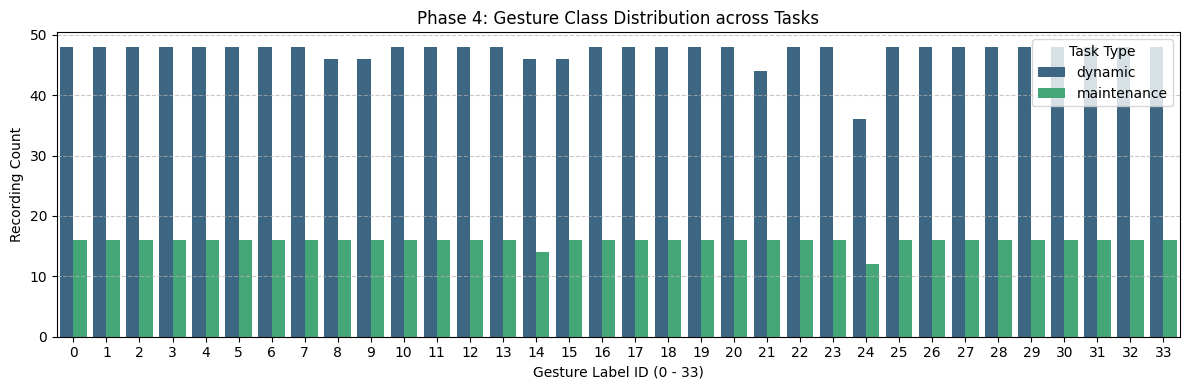


--- Gesture Class Distribution Summary (First 10 Classes) ---
task_type      dynamic  maintenance
gesture_label                      
0                   48           16
1                   48           16
2                   48           16
3                   48           16
4                   48           16
5                   48           16
6                   48           16
7                   48           16
8                   46           16
9                   46           16


/tmp/ipykernel_7196/137622126.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


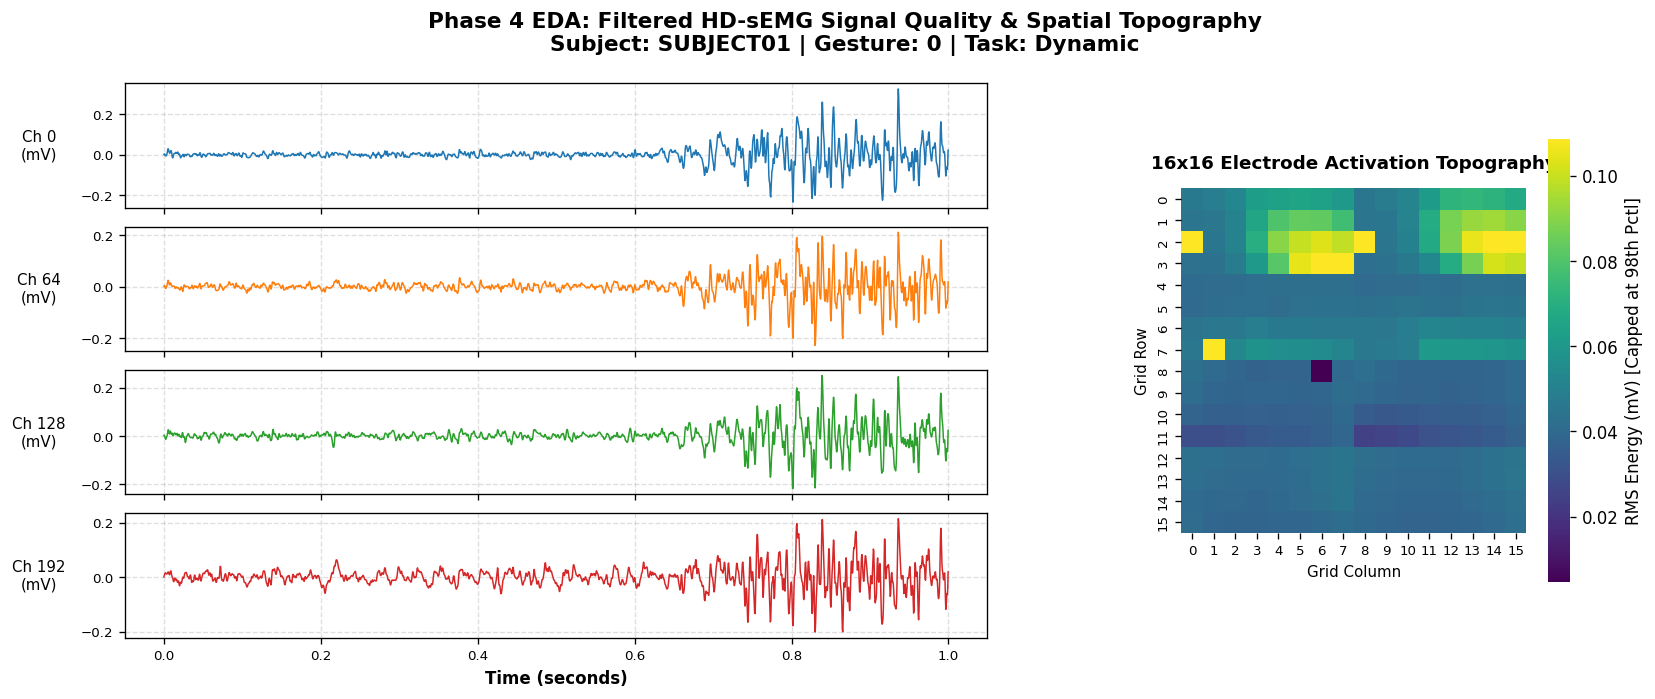

In [ ]:
print("================ PHASE 4: DATA EXPLORATION ================\n")

# Verify using the master metadata DataFrame
sample_rec = wfdb.rdrecord(master_df_meta.iloc[0]["file_prefix"])
print(f"• Raw Signal Matrix Shape: ({sample_rec.sig_len} timesteps, {sample_rec.n_sig} channels)")
print(f"• Sampling Frequency: {sample_rec.fs} Hz")
print(f"• Duration: {sample_rec.sig_len / sample_rec.fs:.2f} seconds")

plt.figure(figsize=(12, 4))
sns.countplot(data=master_df_meta, x="gesture_label", hue="task_type", palette="viridis")
plt.title("Phase 4: Gesture Class Distribution across Tasks")
plt.xlabel("Gesture Label ID (0 - 33)")
plt.ylabel("Recording Count")
plt.legend(title="Task Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

class_counts = master_df_meta.groupby(["gesture_label", "task_type"]).size().unstack(fill_value=0)
print("\n--- Gesture Class Distribution Summary (First 10 Classes) ---")
print(class_counts.head(10))

# Run Visualization on first available sample in master metadata
visualize_raw_emg_sample(master_df_meta, row_index=0)

## Chapter 3 Visual Evidence

The following figures document the implemented dataset scope and preprocessing pipeline using the selected Hyser subset:
Subject 1 and Subject 2, Sessions 1 and 2.


Saved: /content/drive/MyDrive/Dissertation_Figures/fig3_dataset_scope.png


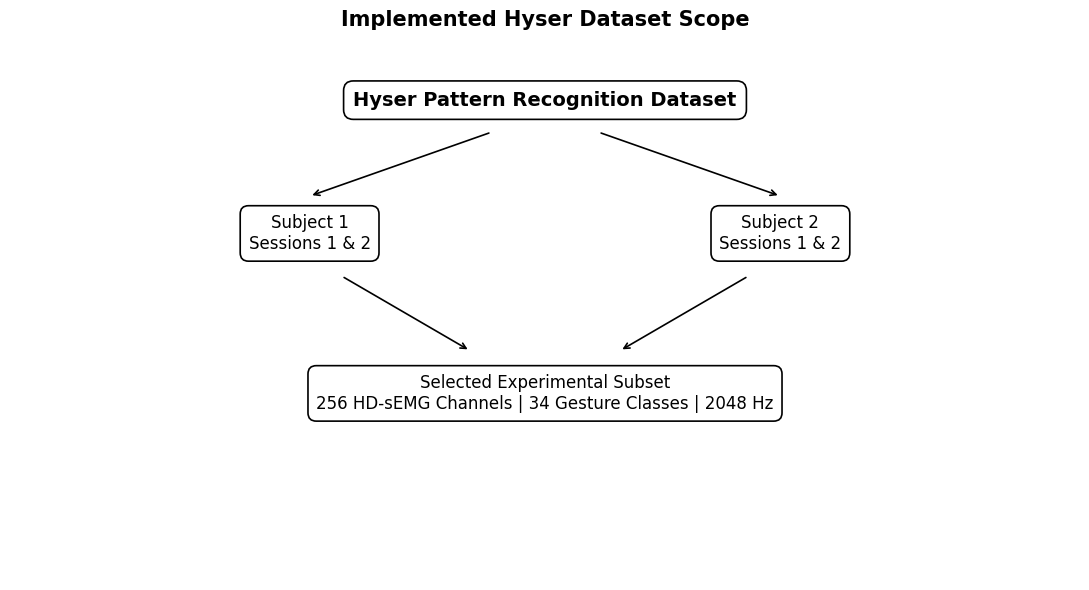

In [ ]:
# Figure 3.x - Implemented Dataset Scope Diagram
fig, ax = plt.subplots(figsize=(11, 6))
ax.axis("off")
box = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="black", linewidth=1.2)
ax.text(0.50, 0.90, "Hyser Pattern Recognition Dataset", ha="center", va="center",
        fontsize=14, fontweight="bold", bbox=box)

ax.text(0.28, 0.65, "Subject 1\nSessions 1 & 2", ha="center", va="center",
        fontsize=12, bbox=box)
ax.text(0.72, 0.65, "Subject 2\nSessions 1 & 2", ha="center", va="center",
        fontsize=12, bbox=box)

ax.text(0.50, 0.35,
        "Selected Experimental Subset\n256 HD-sEMG Channels | 34 Gesture Classes | 2048 Hz",
        ha="center", va="center", fontsize=12, bbox=box)

# connectors
ax.annotate("", xy=(0.28, 0.72), xytext=(0.45, 0.84),
            arrowprops=dict(arrowstyle="->", lw=1.2))
ax.annotate("", xy=(0.72, 0.72), xytext=(0.55, 0.84),
            arrowprops=dict(arrowstyle="->", lw=1.2))
ax.annotate("", xy=(0.43, 0.43), xytext=(0.31, 0.57),
            arrowprops=dict(arrowstyle="->", lw=1.2))
ax.annotate("", xy=(0.57, 0.43), xytext=(0.69, 0.57),
            arrowprops=dict(arrowstyle="->", lw=1.2))

ax.set_title("Implemented Hyser Dataset Scope", fontsize=15, fontweight="bold", pad=15)
plt.tight_layout()
save_figure("fig3_dataset_scope.png")
plt.show()


Saved: /content/drive/MyDrive/Dissertation_Figures/fig3_window_segmentation.png


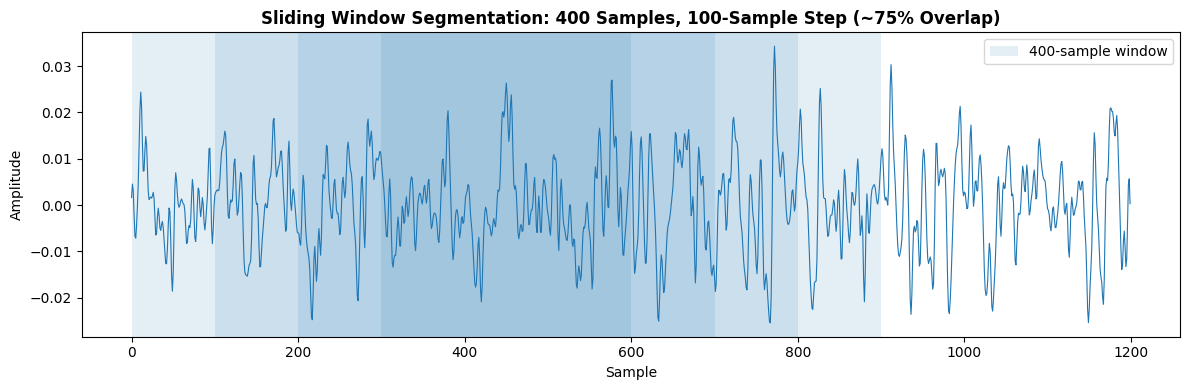

In [ ]:
row = master_df_meta.iloc[0]
rec = wfdb.rdrecord(row["file_prefix"])
raw_sig = rec.p_signal
fs = rec.fs

nyq = 0.5 * fs
b_notch, a_notch = signal.iirnotch(50.0 / nyq, Q=30.0)
b_band, a_band = signal.butter(4, [10.0 / nyq, 500.0 / nyq], btype="bandpass")

filtered_sig = signal.filtfilt(b_notch, a_notch, raw_sig, axis=0)
filtered_sig = signal.filtfilt(b_band, a_band, filtered_sig, axis=0)

time_axis = np.arange(raw_sig.shape[0]) / fs
ch = 64 if raw_sig.shape[1] > 64 else 0

# Figure 3.x - Sliding Window Segmentation
window_size = 400
step_size = 100
display_samples = min(1200, filtered_sig.shape[0])
signal_example = filtered_sig[:display_samples, ch]

plt.figure(figsize=(12, 4))
plt.plot(np.arange(display_samples), signal_example, linewidth=0.8)

window_starts = list(range(0, display_samples - window_size + 1, step_size))
for i, start in enumerate(window_starts[:6]):
    plt.axvspan(start, start + window_size, alpha=0.12,
                label="400-sample window" if i == 0 else None)

plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title(
    "Sliding Window Segmentation: 400 Samples, 100-Sample Step (~75% Overlap)",
    fontweight="bold"
)
plt.legend()
plt.tight_layout()
save_figure("fig3_window_segmentation.png")
plt.show()


In [ ]:
print("================ DATA AUDIT ================\n")

total_dat_files = 0
total_hea_files = 0

for folder in target_folders:
    folder_path = os.path.join(base_dir, folder)
    if os.path.exists(folder_path):
        d_files = glob.glob(os.path.join(folder_path, "*_raw_*.dat"))
        h_files = glob.glob(os.path.join(folder_path, "*_raw_*.hea"))
        total_dat_files += len(d_files)
        total_hea_files += len(h_files)

print(f"Total Downloaded .dat files: {total_dat_files}")
print(f"Total Downloaded .hea files: {total_hea_files}")

# Read first header from master metadata to verify sampling rate and channel setup
if not master_df_meta.empty:
    sample_header = wfdb.rdheader(master_df_meta.iloc[0]["file_prefix"])
    print(f"\nHeader Verification:")
    print(f"Sampling Frequency (fs): {sample_header.fs} Hz")
    print(f"Number of Channels: {sample_header.n_sig}")
    print(f"Signal Length: {sample_header.sig_len} samples ({sample_header.sig_len / sample_header.fs:.2f} seconds)")

================ DATA AUDIT ================

Total Downloaded .dat files: 1073
Total Downloaded .hea files: 1073

Header Verification:
Sampling Frequency (fs): 2048 Hz
Number of Channels: 256
Signal Length: 2048 samples (1.00 seconds)


In [ ]:
print("================ DATASET SPLITTING ================\n")

gc.enable()
# Shuffle the master metadata dataframe
df_meta_shuffled = master_df_meta.sample(frac=1, random_state=SEED).reset_index(drop=True)

num_records = len(df_meta_shuffled)
train_end = int(num_records * 0.70)
val_end = int(num_records * 0.85)

train_df = df_meta_shuffled.iloc[:train_end]
val_df = df_meta_shuffled.iloc[train_end:val_end]
test_df = df_meta_shuffled.iloc[val_end:]

print(
    f"Dataset Split: {len(train_df)} Train | {len(val_df)} Val |"
    f" {len(test_df)} Test records."
)

================ DATASET SPLITTING ================

Dataset Split: 1502 Train | 322 Val | 322 Test records.


Saved: /content/drive/MyDrive/Dissertation_Figures/fig3_record_level_split.png


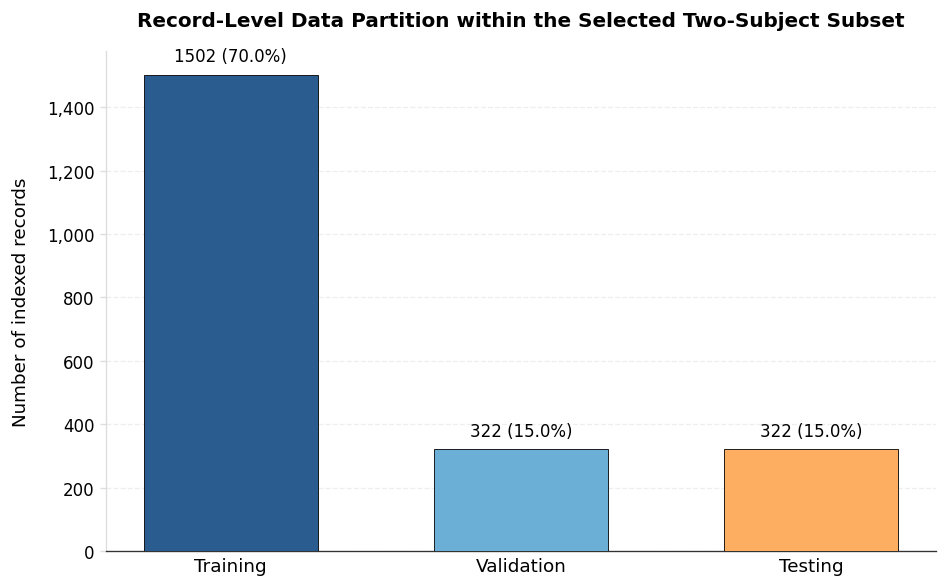

In [ ]:
# Figure 3.x - Record-Level Train / Validation / Test Partition
split_names = ["Training", "Validation", "Testing"]
split_counts = [len(train_df), len(val_df), len(test_df)]
split_percentages = np.array(split_counts) / sum(split_counts) * 100

f, ax = plt.subplots(figsize=(8, 5),dpi=120)
bars = ax.bar(split_names,
              split_counts,
              color =['#2b5c8f', '#6baed6', '#fdae61'],
              edgecolor ='black',
              linewidth=0.5,
              width=0.6,
              zorder=3,
              align='center'
              )


max_height = max(split_counts)
for bar, count, pct in zip(bars, split_counts, split_percentages):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+(max_height*0.02),
        f"{count} ({pct:.1f}%)",
        ha="center", va="bottom", fontsize=10,fontweight='medium'
    )

ax.set_ylabel("Number of indexed records",fontsize=11,labelpad=10)
ax.set_title(
    "Record-Level Data Partition within the Selected Two-Subject Subset",
    fontweight="bold",fontsize=12,pad=15
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#333333')

ax.yaxis.grid(True, linestyle='--', color='#eeeeee')
ax.set_axisbelow(True)

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

ax.tick_params(axis='x', length=0, labelsize=11)
ax.tick_params(axis='y', color='#dddddd', labelsize=10)

f.tight_layout()

f.tight_layout()
save_figure("fig3_record_level_split.png")
plt.show()


In [ ]:
train_dataset = HDsEMGDataset(train_df, window_size=400, step_size=100)
val_dataset = HDsEMGDataset(val_df, window_size=400, step_size=100)
test_dataset = HDsEMGDataset(test_df, window_size=400, step_size=100)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

<h2>Model Pipeline</h2>

In [ ]:
"""
Executing Phase 6: Model Training & Evaluation

This version retains per-epoch training/validation history so dissertation-quality
learning curves can be generated after training.
"""

models = {
    "Baseline CNN": BaselineCNN(in_channels=256, num_classes=34).to(DEVICE),
    "CNN-LSTM": CNN_LSTM(in_channels=256, num_classes=34).to(DEVICE),
    "Attention CNN-LSTM": HighPerfHDsEMGNet(num_classes=34, hidden_dim=256).to(DEVICE)
}

criterion = nn.CrossEntropyLoss()
epochs = 10

# Store training history and clean final-test accuracy
training_history = {}
clean_test_accuracy = {}

for name, model in models.items():
    print(f"\n================ Training Model: {name} ================")

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scaler = GradScaler('cuda')

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(1, epochs + 1):
        # --- Training Step ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x_b)
                loss = criterion(outputs, y_b)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * x_b.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == y_b).item()
            total += y_b.size(0)

        train_acc = (correct / total) * 100
        train_loss = running_loss / total

        # --- Validation Step ---
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for x_v, y_v in val_loader:
                x_v, y_v = x_v.to(DEVICE), y_v.to(DEVICE)

                with autocast(device_type='cuda'):
                    val_out = model(x_v)
                    val_loss = criterion(val_out, y_v)
                    _, preds = torch.max(val_out, 1)

                val_running_loss += val_loss.item() * x_v.size(0)
                val_correct += torch.sum(preds == y_v).item()
                val_total += y_v.size(0)

        val_acc = (val_correct / val_total) * 100
        val_loss_epoch = val_running_loss / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss_epoch)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:02d}/{epochs:02d} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss_epoch:.4f} | Val Acc: {val_acc:.2f}%"
        )

    training_history[name] = history

    # --- Final Test Evaluation ---
    model.eval()
    test_correct, test_total = 0, 0

    with torch.no_grad():
        for x_t, y_t in test_loader:
            x_t, y_t = x_t.to(DEVICE), y_t.to(DEVICE)

            with autocast(device_type='cuda'):
                test_out = model(x_t)
                _, preds = torch.max(test_out, 1)

            test_correct += torch.sum(preds == y_t).item()
            test_total += y_t.size(0)

    test_acc = (test_correct / test_total) * 100
    clean_test_accuracy[name] = test_acc
    print(f"--> Final Test Accuracy [{name}]: {test_acc:.2f}%")



================ Training Model: Baseline CNN ================
Epoch 01/10 | Train Loss: 0.9415 | Train Acc: 76.30% | Val Loss: 0.4647 | Val Acc: 86.34%
Epoch 02/10 | Train Loss: 0.2600 | Train Acc: 92.79% | Val Loss: 0.4917 | Val Acc: 85.13%
Epoch 03/10 | Train Loss: 0.1601 | Train Acc: 95.46% | Val Loss: 0.2742 | Val Acc: 91.05%
Epoch 04/10 | Train Loss: 0.1203 | Train Acc: 96.43% | Val Loss: 0.3076 | Val Acc: 90.27%
Epoch 05/10 | Train Loss: 0.0897 | Train Acc: 97.33% | Val Loss: 0.2889 | Val Acc: 91.44%
Epoch 06/10 | Train Loss: 0.0694 | Train Acc: 97.90% | Val Loss: 0.3224 | Val Acc: 90.63%
Epoch 07/10 | Train Loss: 0.0656 | Train Acc: 97.91% | Val Loss: 0.3656 | Val Acc: 89.99%
Epoch 08/10 | Train Loss: 0.0581 | Train Acc: 98.15% | Val Loss: 0.2325 | Val Acc: 92.41%
Epoch 09/10 | Train Loss: 0.0473 | Train Acc: 98.53% | Val Loss: 0.1513 | Val Acc: 95.50%
Epoch 10/10 | Train Loss: 0.0423 | Train Acc: 98.74% | Val Loss: 0.2077 | Val Acc: 93.42%
--> Final Test Accuracy [Baseline CN

In [ ]:
test_results = {}

for name, model in models.items():
    model.eval()
    all_preds = []
    all_trues = []

    with torch.no_grad():
        for x_t, y_t in test_loader:
            x_t, y_t = x_t.to(DEVICE), y_t.to(DEVICE)

            with autocast(device_type='cuda'):
                test_out = model(x_t)
                _, preds = torch.max(test_out, 1)

            all_preds.extend(preds.cpu().numpy())
            all_trues.extend(y_t.cpu().numpy())

    test_results[name] = {
        "y_true": np.array(all_trues),
        "y_pred": np.array(all_preds)
    }
    print(f"Collected predictions for {name}")

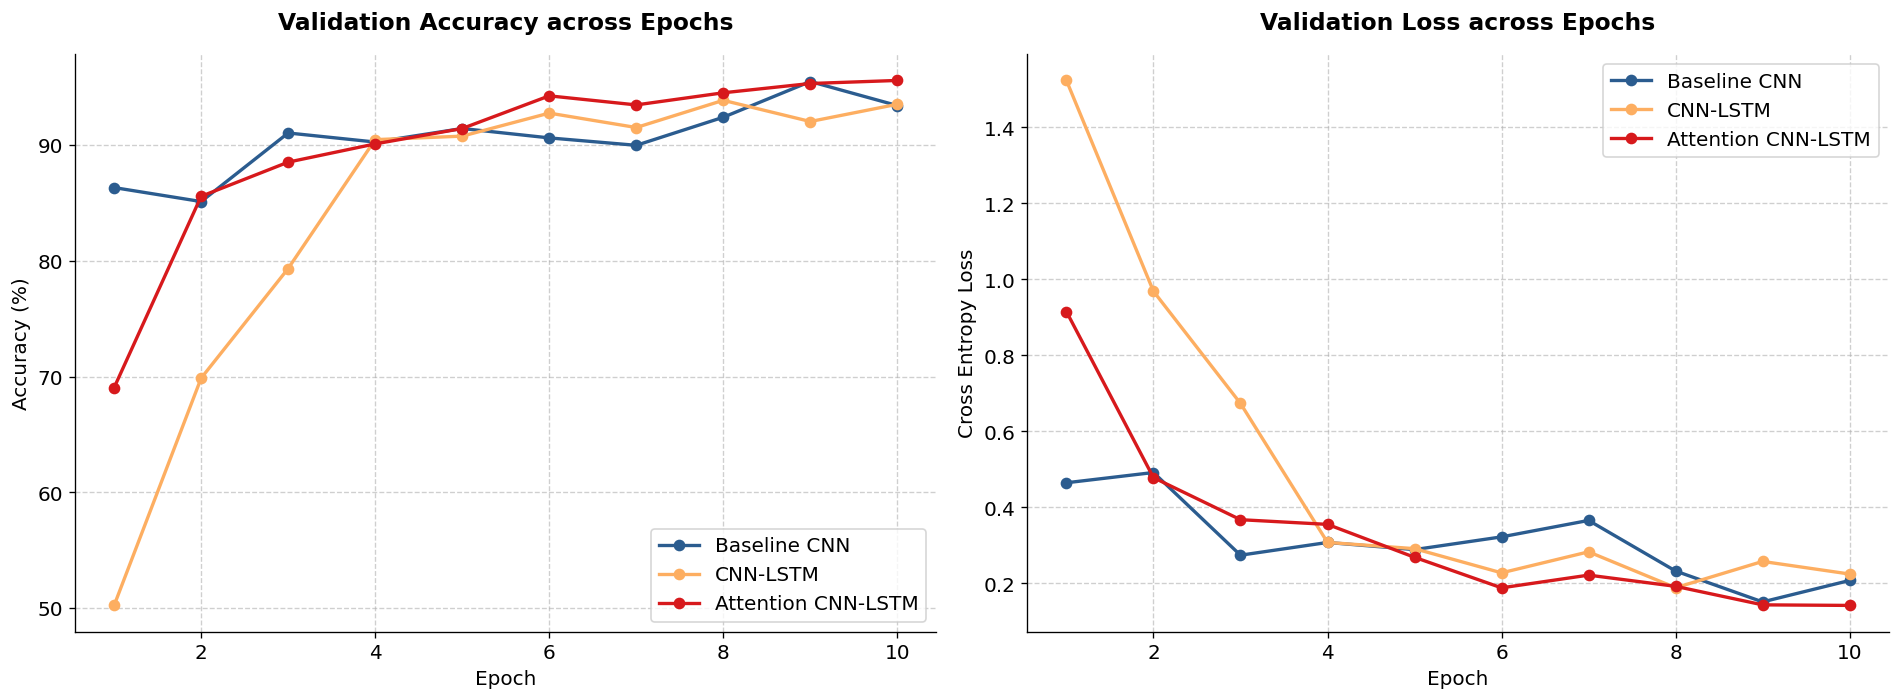

In [ ]:
plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12})
colors = ['#2b5c8f', '#fdae61', '#d7191c'] # Blue, Orange, Red

fig1, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=120)
epochs_range = range(1, epochs + 1)
for idx, (name, history) in enumerate(training_history.items()):
    # Plot Validation Accuracy
    axes[0].plot(epochs_range, history['val_acc'], label=name, color=colors[idx], linewidth=2, marker='o')
    # Plot Validation Loss
    axes[1].plot(epochs_range, history['val_loss'], label=name, color=colors[idx], linewidth=2, marker='o')

# Accuracy Plot Styling
axes[0].set_title("Validation Accuracy across Epochs", fontweight='bold', pad=15)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# Loss Plot Styling
axes[1].set_title("Validation Loss across Epochs", fontweight='bold', pad=15)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross Entropy Loss")
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

fig1.tight_layout()
plt.savefig("fig4_learning_curves.png", dpi=300)
plt.show()


In [ ]:
# =====================================================================
# Figure 2: Final Test Accuracy Comparison (Bar Chart)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(8, 6), dpi=120)

model_names = list(clean_test_accuracy.keys())
accuracies = list(clean_test_accuracy.values())

bars = ax2.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.6)

# Add text above bars
for bar, acc in zip(bars, accuracies):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{acc:.2f}%",
        ha="center", va="bottom", fontweight='bold'
    )

ax2.set_title("Final Test Accuracy Comparison", fontweight='bold', pad=15)
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, max(accuracies) + 10) # Give headroom for text
ax2.yaxis.grid(True, linestyle='--', alpha=0.6)
ax2.set_axisbelow(True)
ax2.spines[['top', 'right']].set_visible(False)

fig2.tight_layout()
plt.savefig("fig5_test_accuracy_bar.png", dpi=300)
plt.show()



The training and evaluation loop above will train each model for 10 epochs, reporting training and validation accuracy after each epoch, and finally reporting the test accuracy for each model. Adjust the number of epochs as needed based on your computational resources and desired performance.


<h2>Multi-Modal Noise Robustness Benchmark</h2>

In [ ]:
# Phase 10: Define Evaluation Scenarios
# We will evaluate the robustness of the trained models
# under various noise conditions, including different levels
# of Additive White Gaussian Noise (AWGN) and channel dropout scenarios.
# The following dictionary defines the specific noise conditions to be tested.
noise_conditions = {
    "Clean": {"snr": None, "dropout": 0.0},
    "AWGN 20dB": {"snr": 20, "dropout": 0.0},
    "AWGN 10dB": {"snr": 10, "dropout": 0.0},
    "AWGN 5dB": {"snr": 5, "dropout": 0.0},
    "AWGN 0dB": {"snr": 0, "dropout": 0.0},
    "Dropout 10%": {"snr": None, "dropout": 0.1},
    "Dropout 20%": {"snr": None, "dropout": 0.2},
    "Dropout 30%": {"snr": None, "dropout": 0.3},
}

# Baseline clean feature extraction for offline LDA training
# We will extract the penultimate layer features from the clean training dataset
train_clean_dataset = HDsEMGDataset(train_df, window_size=400, step_size=100)
train_clean_loader = DataLoader(train_clean_dataset, batch_size=64, shuffle=False)

full_results = []

# Phase 11: Evaluate each model under defined noise conditions
for model_name, model in models.items():
    print(f"\n--- Running Noise Robustness Pipeline: {model_name} ---")

    # Phase 8: Extract clean bottleneck features for training offline LDA classifier
    # We will use the clean training dataset to fit the LDA model, which will then be evaluated under various noise conditions.
    train_feats, train_labels = extract_penultimate_features(model, train_clean_loader, DEVICE)
    lda_clf = LDA()
    lda_clf.fit(train_feats, train_labels)

    for cond_name, params in noise_conditions.items():
        test_dataset = HDsEMGDataset(
            test_df,
            window_size=400,
            step_size=100,
            snr_db=params["snr"],
            channel_dropout=params["dropout"]
        )
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

        # Extract features and direct Softmax predictions under noisy conditions
        test_feats, test_labels = extract_penultimate_features(model, test_loader, DEVICE)

        # 1. Evaluate Direct Deep Learning Classifier Head
        model.eval()
        direct_preds = []
        with torch.no_grad():
            for x_b, _ in test_loader:
                x_b = x_b.to(DEVICE)
                out = model(x_b)
                direct_preds.append(torch.argmax(out, dim=1).cpu().numpy())
        direct_preds = np.concatenate(direct_preds)

        direct_acc = accuracy_score(test_labels, direct_preds)
        _, _, direct_f1, _ = precision_recall_fscore_support(test_labels, direct_preds, average='macro', zero_division=0)

        # 2. Evaluate Downstream LDA on Bottleneck Feature Embeddings
        lda_preds = lda_clf.predict(test_feats)
        lda_acc = accuracy_score(test_labels, lda_preds)
        _, _, lda_f1, _ = precision_recall_fscore_support(test_labels, lda_preds, average='macro', zero_division=0)

        full_results.append({
            "Model": model_name,
            "Condition": cond_name,
            "Direct Acc (%)": round(direct_acc * 100, 2),
            "Direct F1": round(direct_f1, 4),
            "Bottleneck+LDA Acc (%)": round(lda_acc * 100, 2),
            "Bottleneck+LDA F1": round(lda_f1, 4)
        })

df_metrics = pd.DataFrame(full_results)
print("\n--- Robustness Benchmark Metrics ---")
print(df_metrics)


--- Running Noise Robustness Pipeline: Baseline CNN ---

--- Running Noise Robustness Pipeline: CNN-LSTM ---

--- Running Noise Robustness Pipeline: Attention CNN-LSTM ---

--- Robustness Benchmark Metrics ---
                 Model    Condition  Direct Acc (%)  Direct F1  \
0         Baseline CNN        Clean           92.81     0.9244   
1         Baseline CNN    AWGN 20dB           92.80     0.9243   
2         Baseline CNN    AWGN 10dB           92.39     0.9197   
3         Baseline CNN     AWGN 5dB           91.41     0.9083   
4         Baseline CNN     AWGN 0dB           85.15     0.8422   
5         Baseline CNN  Dropout 10%           79.23     0.7830   
6         Baseline CNN  Dropout 20%           65.27     0.6446   
7         Baseline CNN  Dropout 30%           50.91     0.5035   
8             CNN-LSTM        Clean           93.82     0.9372   
9             CNN-LSTM    AWGN 20dB           93.75     0.9363   
10            CNN-LSTM    AWGN 10dB           93.31     0.9322 

## Chapter 4 - Core Results Visualisations

These figures are generated directly from `df_metrics` produced by the implemented robustness experiment.
AWGN is the primary robustness experiment; channel dropout is treated as supplementary analysis.


In [ ]:
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.title_fontsize': 11,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 2,
    'lines.markersize': 7
})

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 's', '^']  # Circle, Square, Triangle for B&W print distinction

def get_style_args(model_name, model_list):
    """Helper to ensure consistent colors/markers across all plots."""
    idx = list(model_list).index(model_name)
    return {'color': colors[idx % len(colors)], 'marker': markers[idx % len(markers)]}

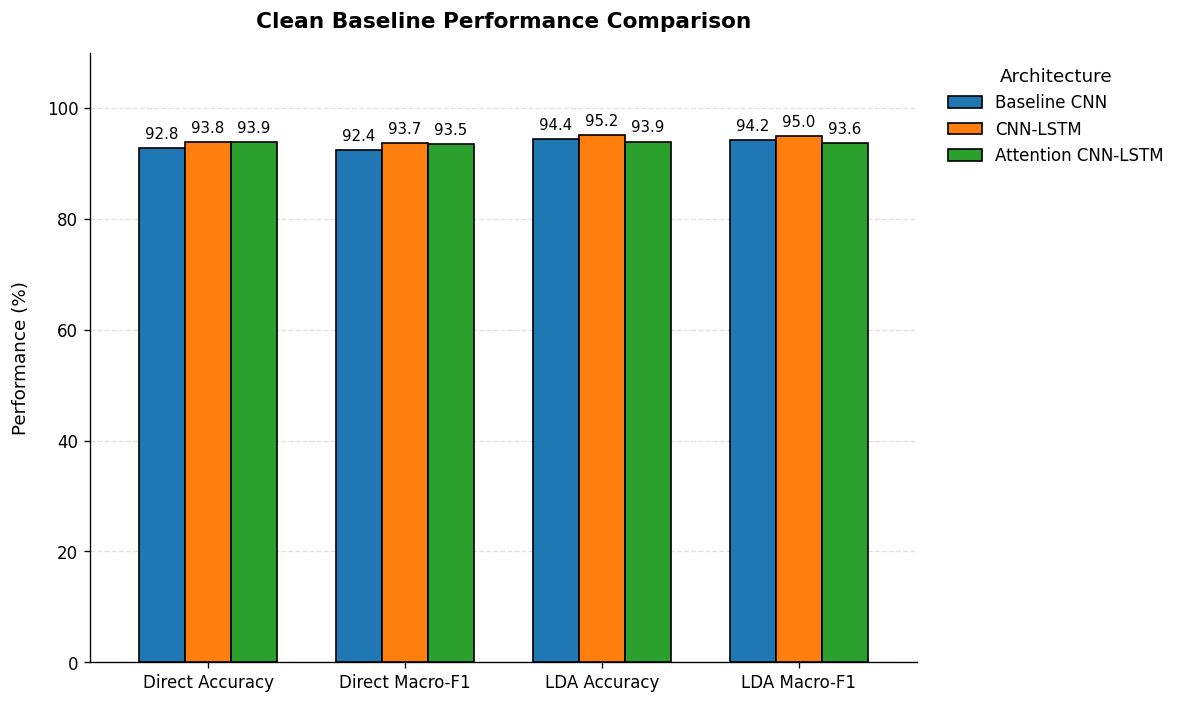

In [ ]:
clean_df = df_metrics[df_metrics["Condition"] == "Clean"].copy()

baseline_plot = clean_df.set_index("Model")[
    ["Direct Acc (%)", "Direct F1", "Bottleneck+LDA Acc (%)", "Bottleneck+LDA F1"]
].copy()

# Standardize to 0-100 scale
baseline_plot["Direct F1"] *= 100
baseline_plot["Bottleneck+LDA F1"] *= 100
baseline_plot.columns = [
    "Direct Accuracy", "Direct Macro-F1", "LDA Accuracy", "LDA Macro-F1"
]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars with edge color for definition
baseline_plot.T.plot(
    kind="bar", ax=ax, color=colors, edgecolor='black', width=0.7, zorder=3
)

ax.set_ylabel("Performance (%)", labelpad=10)
ax.set_title("Clean Baseline Performance Comparison", fontweight="bold", pad=15)
ax.set_ylim(0, 110) # Extra room for annotations
ax.yaxis.grid(True, linestyle='--', color='#e0e0e0', zorder=0)

# Annotate bars with values
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', xytext=(0, 4),
        textcoords='offset points', fontsize=9
    )

plt.xticks(rotation=0) # Kept horizontal if names are short enough, else use 15
ax.legend(title="Architecture", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
plt.savefig("fig4_clean_baseline.png", bbox_inches="tight")
plt.show()

In [ ]:
# -----------------------------
# Figure 2: Direct vs. LDA under AWGN (1x2 Panel)
# -----------------------------
awgn_order = ["Clean", "AWGN 20dB", "AWGN 10dB", "AWGN 5dB", "AWGN 0dB"]
awgn_df = df_metrics[df_metrics["Condition"].isin(awgn_order)].copy()
awgn_df["Condition"] = pd.Categorical(awgn_df["Condition"], categories=awgn_order, ordered=True)
awgn_df = awgn_df.sort_values(["Model", "Condition"])
models_unique = awgn_df["Model"].unique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)

# Panel A: Direct F1
for m in models_unique:
    subset = awgn_df[awgn_df["Model"] == m]
    style = get_style_args(m, models_unique)
    axes[0].plot(subset["Condition"].astype(str), subset["Direct F1"], label=m, **style)

axes[0].set_title("(A) Direct Classifier Robustness", fontweight="bold", pad=10)
axes[0].set_ylabel("Macro-F1 Score")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel B: LDA F1
for m in models_unique:
    subset = awgn_df[awgn_df["Model"] == m]
    style = get_style_args(m, models_unique)
    axes[1].plot(subset["Condition"].astype(str), subset["Bottleneck+LDA F1"], label=m, **style)

axes[1].set_title("(B) Learned-Representation (LDA) Robustness", fontweight="bold", pad=10)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Single legend for both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)

plt.tight_layout()
# Adjust bottom to make room for the shared legend
plt.subplots_adjust(bottom=0.2)
plt.savefig("fig5_awgn_direct_vs_lda.png")
plt.show()

In [ ]:
# -----------------------------
# Figure 3: Performance Retention & Channel Dropout
# -----------------------------
# Calculate Retention
retention_rows = []
for m in models_unique:
    subset = awgn_df[awgn_df["Model"] == m].copy()
    clean_f1 = float(subset.loc[subset["Condition"] == "Clean", "Bottleneck+LDA F1"].iloc[0])
    for _, row in subset.iterrows():
        retention_rows.append({
            "Model": m,
            "Condition": str(row["Condition"]),
            "Retention (%)": (row["Bottleneck+LDA F1"] / clean_f1) * 100
        })
retention_df = pd.DataFrame(retention_rows)

# Dropout Data setup
drop_order = ["Clean", "Dropout 10%", "Dropout 20%", "Dropout 30%"]
drop_df = df_metrics[df_metrics["Condition"].isin(drop_order)].copy()
drop_df["Condition"] = pd.Categorical(drop_df["Condition"], categories=drop_order, ordered=True)
drop_df = drop_df.sort_values(["Model", "Condition"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: Retention under AWGN
for m in models_unique:
    subset = retention_df[retention_df["Model"] == m]
    style = get_style_args(m, models_unique)
    axes[0].plot(subset["Condition"], subset["Retention (%)"], label=m, **style)

axes[0].axhline(100, color='gray', linestyle=':', linewidth=1.5, zorder=0) # 100% Reference
axes[0].set_title("(A) Performance Retention under AWGN", fontweight="bold", pad=10)
axes[0].set_ylabel("Clean LDA Performance Retained (%)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel B: Dropout LDA F1
for m in models_unique:
    subset = drop_df[drop_df["Model"] == m]
    style = get_style_args(m, models_unique)
    axes[1].plot(subset["Condition"].astype(str), subset["Bottleneck+LDA F1"], label=m, **style)

axes[1].set_title("(B) Channel-Dropout Robustness (LDA)", fontweight="bold", pad=10)
axes[1].set_ylabel("LDA Macro-F1")
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, linestyle='--', alpha=0.5)

# Shared Legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.savefig("fig6_retention_and_dropout.png")
plt.show()

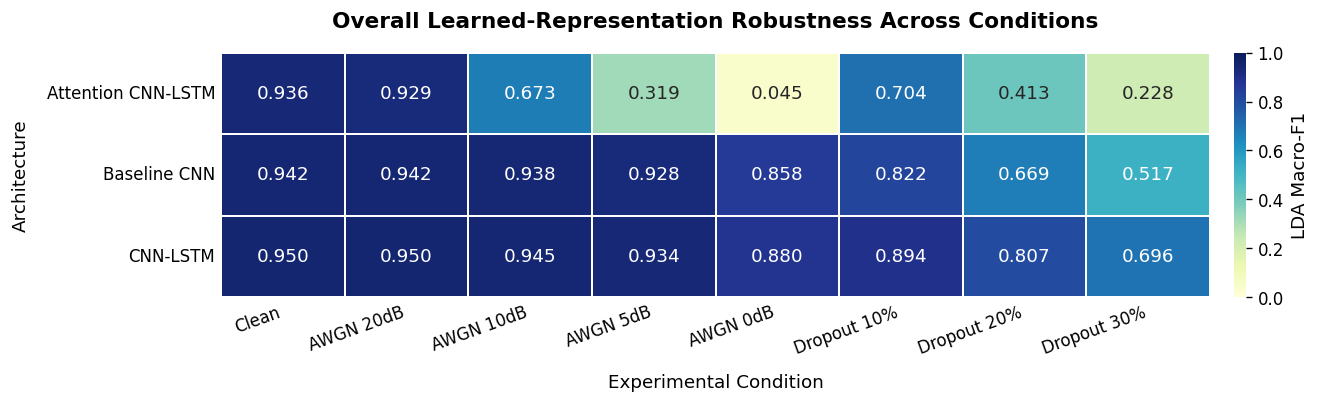

In [ ]:
# -----------------------------
# Figure 4: Overall Robustness Heatmap
# -----------------------------
condition_order = [
    "Clean", "AWGN 20dB", "AWGN 10dB", "AWGN 5dB", "AWGN 0dB",
    "Dropout 10%", "Dropout 20%", "Dropout 30%"
]

heatmap_df = df_metrics.pivot(
    index="Model",
    columns="Condition",
    values="Bottleneck+LDA F1"
).reindex(columns=condition_order)

# Adjust figsize so cells are perfectly proportioned
fig, ax = plt.subplots(figsize=(12, 3.5))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    vmin=0.0,
    vmax=1.0,
    cmap="YlGnBu",          # Highly professional print colormap
    cbar_kws={"label": "LDA Macro-F1", "pad": 0.02},
    linewidths=1,           # Add borders between cells
    linecolor='white',
    ax=ax
)

ax.set_title("Overall Learned-Representation Robustness Across Conditions", fontweight="bold", pad=15)
ax.set_xlabel("Experimental Condition", labelpad=10)
ax.set_ylabel("Architecture", labelpad=10)

# Improve x-axis readability
plt.xticks(rotation=20, ha="right")
ax.tick_params(axis='both', which='both', length=0) # Remove tick marks for clean look

plt.tight_layout()
plt.savefig("fig7_overall_robustness_heatmap.png")
plt.show()

<h2>Dimensionality Reduction & Visualization</h2>

In [ ]:
MAX_TSNE_PER_CONDITION = 700
tsne_results = {}

for model_name, target_model in models.items():
    print(f"Extracting & computing joint t-SNE for: {model_name}...")

    clean_test_ds = HDsEMGDataset(test_df, window_size=400, step_size=100, snr_db=None)
    noisy_test_ds = HDsEMGDataset(test_df, window_size=400, step_size=100, snr_db=0)

    clean_loader = DataLoader(clean_test_ds, batch_size=64, shuffle=False)
    noisy_loader = DataLoader(noisy_test_ds, batch_size=64, shuffle=False)

    clean_feats, clean_lbls = extract_penultimate_features(target_model, clean_loader, DEVICE)
    noisy_feats, noisy_lbls = extract_penultimate_features(target_model, noisy_loader, DEVICE)

    n = min(MAX_TSNE_PER_CONDITION, len(clean_feats), len(noisy_feats))
    combined_feats = np.vstack([clean_feats[:n], noisy_feats[:n]])

    tsne = TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto")
    embedded = tsne.fit_transform(combined_feats)

    tsne_results[model_name] = {
        "clean": embedded[:n],
        "noisy": embedded[n:]
    }

num_models = len(tsne_results)
fig, axes = plt.subplots(1, num_models, figsize=(5.5 * num_models, 5.5), dpi=150)

if num_models == 1:
    axes = [axes]

colors = {'clean': '#2b5c8f', 'noisy': '#d7191c'}

for ax, (model_name, embeddings) in zip(axes, tsne_results.items()):
    clean_emb = embeddings["clean"]
    noisy_emb = embeddings["noisy"]
    sns.kdeplot(x=clean_emb[:, 0], y=clean_emb[:, 1], ax=ax, cmap="Blues", fill=False, alpha=0.5, levels=4, linewidths=1)
    sns.kdeplot(x=noisy_emb[:, 0], y=noisy_emb[:, 1], ax=ax, cmap="Reds", fill=False, alpha=0.5, levels=4, linewidths=1)

    ax.scatter(
        clean_emb[:, 0], clean_emb[:, 1],
        s=25, c=colors['clean'], marker='o', alpha=0.7,
        edgecolors='white', linewidths=0.4, label="Clean"
    )

    ax.scatter(
        noisy_emb[:, 0], noisy_emb[:, 1],
        s=25, c=colors['noisy'], marker='X', alpha=0.7,
        edgecolors='white', linewidths=0.4, label="0 dB AWGN"
    )

    ax.set_title(model_name, fontweight="bold", pad=12)
    ax.set_xlabel("t-SNE Dim 1")

    if ax == axes[0]:
        ax.set_ylabel("t-SNE Dim 2")

    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

plt.suptitle("Latent Space Domain Shift: Clean vs. 0 dB AWGN", fontweight="bold", fontsize=15, y=1.02)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False,
    fontsize=12,
    markerscale=1.5
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
save_figure("fig8_joint_tsne_domain_shift.png")
plt.show()

In [ ]:
# Non-Parametric Friedman Test across noise conditions
# We will statistically assess whether there are significant
# differences in model performance across different noise conditions
# using the Friedman test, which is suitable for repeated
pivot_f1 = df_metrics.pivot(index='Condition', columns='Model', values='Direct F1')
print("--- F1-Scores Across Noise Conditions ---")
print(pivot_f1)

stat, p_val = friedmanchisquare(pivot_f1["Baseline CNN"], pivot_f1["CNN-LSTM"], pivot_f1["Attention CNN-LSTM"])
print(f"\nFriedman Test Statistic: {stat:.4f}, p-value: {p_val:.4e}")
if p_val < 0.05:
    print("Result: Statistically significant performance differences exist between architectures across noise levels.")

# Computational Efficiency Profile
efficiency_summary = []
sample_input = torch.randn(1, 256, 400).to(DEVICE)

for name, model in models.items():
    model.eval()
    params = sum(p.numel() for p in model.parameters())

    # Latency Timing
    start_time = time.time()
    with torch.no_grad():
        for _ in range(100):
            _ = model(sample_input)
    latency_ms = ((time.time() - start_time) / 100.0) * 1000.0

    efficiency_summary.append({
        "Model Architecture": name,
        "Total Parameters": f"{params:,}",
        "Inference Latency (ms)": round(latency_ms, 2)
    })

print("\n--- Trade-off & Decision Matrix Summary ---")
df_efficiency = pd.DataFrame(efficiency_summary)
print(df_efficiency)

In [ ]:
df_eff_plot = df_efficiency.copy()
df_eff_plot["Parameters Numeric"] = (
    df_eff_plot["Total Parameters"].astype(str).str.replace(",", "", regex=False).astype(int)
)

architectures = df_eff_plot["Model Architecture"].tolist()
params = df_eff_plot["Parameters Numeric"].tolist()
latencies = df_eff_plot["Inference Latency (ms)"].tolist()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), dpi=150)
bars1 = axes[0].bar(architectures, params, color=colors, edgecolor='black', width=0.6, zorder=3)
axes[0].set_title("(A) Model Parameter Count", fontweight="bold", pad=15)
axes[0].set_ylabel("Trainable Parameters", labelpad=10)

def format_params(x, pos):
    if x >= 1e6: return f'{x*1e-6:.1f}M'
    elif x >= 1e3: return f'{x*1e-3:.0f}K'
    else: return str(int(x))
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(format_params))

# Annotate bars with exact comma-separated values
max_params = max(params)
for bar, p in zip(bars1, params):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (max_params * 0.02), # 2% visual offset
        f"{p:,}",
        ha="center", va="bottom", fontsize=10, fontweight="medium"
    )

# --- Panel B: Inference Latency ---
bars2 = axes[1].bar(architectures, latencies, color=colors, edgecolor='black', width=0.6, zorder=3)
axes[1].set_title("(B) Mean Inference Latency", fontweight="bold", pad=15)
axes[1].set_ylabel("Latency (ms)", labelpad=10)

# Annotate bars with latency values
max_latency = max(latencies)
for bar, l in zip(bars2, latencies):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (max_latency * 0.02),
        f"{l:.2f} ms",
        ha="center", va="bottom", fontsize=10, fontweight="medium"
    )

# --- Global Axis Styling ---
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.yaxis.grid(True, linestyle='--', color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)

    # Rotate architecture names slightly for better fit if they are long
    ax.set_xticks(range(len(architectures)))
    ax.set_xticklabels(architectures, rotation=15, ha="right", fontsize=11)

    # Expand Y-limits slightly so top annotations aren't cut off
    ax.set_ylim(0, ax.get_ylim()[1] * 1.08)

plt.tight_layout()
save_figure("fig9_efficiency_tradeoffs.png")
plt.show()


In [ ]:
friedman_summary = pd.DataFrame([{
    "Statistical Test": "Friedman",
    "Target Metric": "Direct Macro-F1",
    "Statistic (Q)": round(stat, 4),
    "p-value": f"{p_val:.2e}" if p_val < 0.001 else round(p_val, 4),
    "Interpretation": (
        "Significant variance across architectures" if p_val < 0.05
        else "No statistically significant variance"
    )
}])

print("\n=== Standard DataFrame Output ===")
display(friedman_summary)


=== Standard DataFrame Output ===


,Statistical Test,Target Metric,Statistic (Q),p-value,Interpretation
0,Friedman,Direct Macro-F1,14.25,8.05e-04,Significant variance across architectures


To replicate the analysis these are the system resources needed. Otherwise the model will crush each time

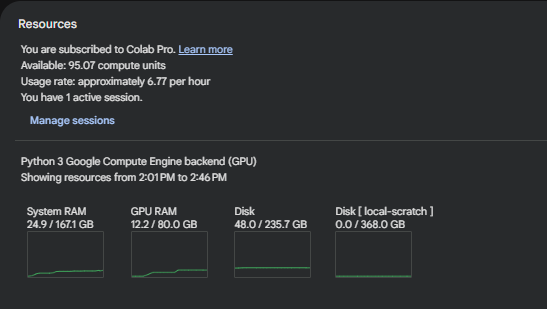